In [ ]:
import pandas as pd
import scipy as stats

data = pd.read_csv('/content/heart_attack_risk_dataset.csv')

df = data.copy()

In [ ]:
df.describe()

,Age,Smoking,Alcohol_Consumption,BMI,Diabetes,Hypertension,Cholesterol_Level,Resting_BP,Heart_Rate,Family_History,Fasting_Blood_Sugar,Exercise_Induced_Angina,Max_Heart_Rate_Achieved
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000
mean,53.398700,0.298420,0.401980,27.519357,0.198840,0.29738,225.036444,134.434100,94.530480,0.30034,0.149360,0.201640,149.305340
std,20.799006,0.457569,0.490303,7.225176,0.399131,0.45711,43.317373,25.907961,20.187124,0.45841,0.356447,0.401229,28.823699
min,18.000000,0.000000,0.000000,15.000000,0.000000,0.00000,150.000000,90.000000,60.000000,0.00000,0.000000,0.000000,100.000000
25%,35.000000,0.000000,0.000000,21.270000,0.000000,0.00000,187.300000,112.000000,77.000000,0.00000,0.000000,0.000000,124.000000
50%,53.000000,0.000000,0.000000,27.540000,0.000000,0.00000,225.100000,134.000000,94.000000,0.00000,0.000000,0.000000,149.000000
75%,71.000000,1.000000,1.000000,33.770000,0.000000,1.00000,262.600000,157.000000,112.000000,1.00000,0.000000,0.000000,174.000000
max,89.000000,1.000000,1.000000,40.000000,1.000000,1.00000,300.000000,179.000000,129.000000,1.00000,1.000000,1.000000,199.000000


In [ ]:
df.shape

(50000, 20)

In [ ]:
print(df.isnull().sum())

Age                        0
Gender                     0
Smoking                    0
Alcohol_Consumption        0
Physical_Activity_Level    0
BMI                        0
Diabetes                   0
Hypertension               0
Cholesterol_Level          0
Resting_BP                 0
Heart_Rate                 0
Family_History             0
Stress_Level               0
Chest_Pain_Type            0
Thalassemia                0
Fasting_Blood_Sugar        0
ECG_Results                0
Exercise_Induced_Angina    0
Max_Heart_Rate_Achieved    0
Heart_Attack_Risk          0
dtype: int64


NameError: name 'plt' is not defined

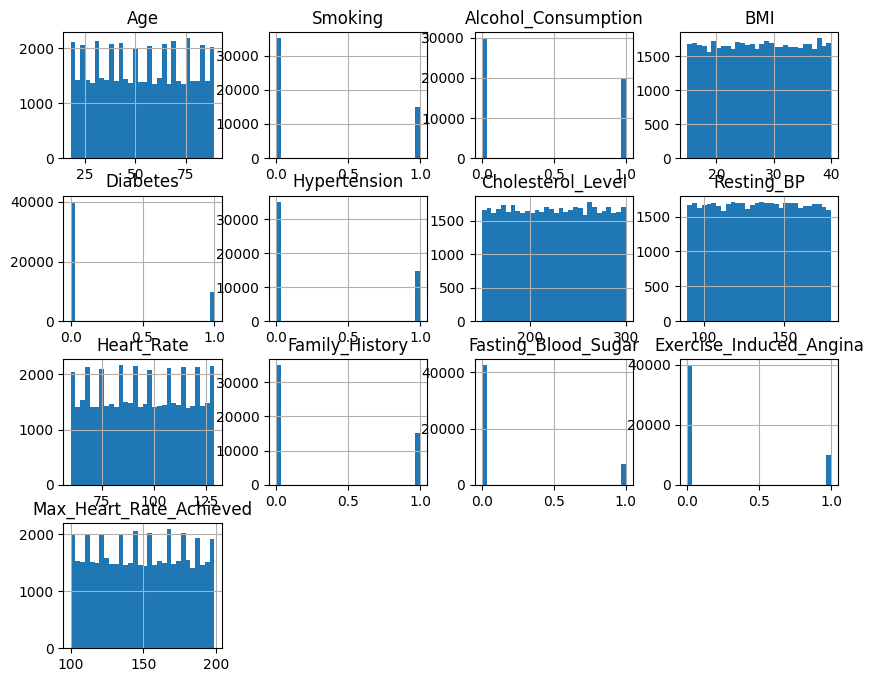

In [ ]:
df.hist(figsize=(10, 8), bins=30)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Separate features and target variable
X = df.drop(columns=['Heart_Attack_Risk'])  # Features
y = df['Heart_Attack_Risk']  # Target

In [ ]:
features = ["Age",
            "Alcohol_Consumption",
            "BMI",
            "Cholesterol_Level",
            "Family_History",
            "Stress_Level"]



In [ ]:
# Convert categorical variables (if any) using One-Hot Encoding
X = pd.get_dummies(df[features], drop_first=True)

In [ ]:
# Split dataset into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
rf_model = RandomForestClassifier(random_state=42)

In [ ]:
# Define hyperparameter grid for tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

In [ ]:
# Perform GridSearchCV to find the best parameters
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [ ]:
# Get the best estimator
best_rf_model = grid_search.best_estimator_

In [ ]:
# Make predictions
y_pred = best_rf_model.predict(X_test)

In [ ]:
# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f'Best Model Accuracy: {accuracy:.2f}')

In [ ]:
# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

In [ ]:
# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

In [ ]:
# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.43


In [ ]:
# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

        High       0.17      0.08      0.11      2986
         Low       0.50      0.70      0.59      7567
    Moderate       0.29      0.20      0.23      4447

    accuracy                           0.43     15000
   macro avg       0.32      0.33      0.31     15000
weighted avg       0.37      0.43      0.39     15000

Confusion Matrix:
 [[ 232 2121  633]
 [ 695 5318 1554]
 [ 421 3147  879]]


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Set seaborn style for better visuals
sns.set_style("whitegrid")

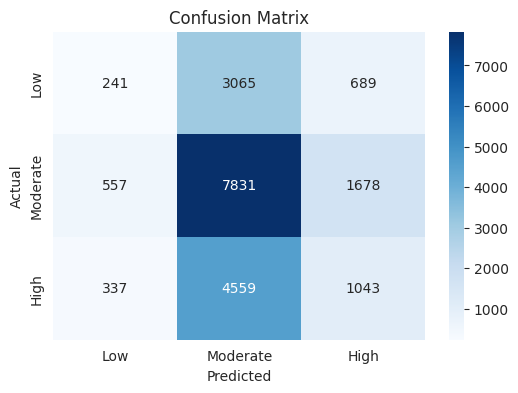

In [ ]:
cm = confusion_matrix(y_test, y_pred)


# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Low", "Moderate","High"], yticklabels=["Low", "Moderate","High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

In [ ]:
print(cm_percentage)

[[ 6.4921993  76.04428787 17.46351283]
 [ 6.61026953 76.01809955 17.37163093]
 [ 7.06484642 75.66552901 17.26962457]]


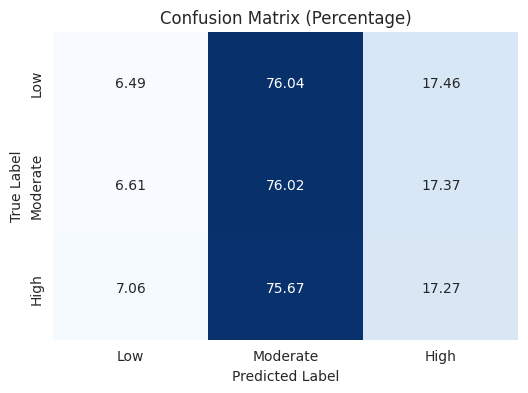

In [ ]:
# Create a DataFrame for better visualization
# Get class labels
cm_df = pd.DataFrame(cm_percentage, index=["Low", "Moderate", "High"], columns=["Low", "Moderate", "High"])

# Plot confusion matrix with percentages
plt.figure(figsize=(6, 4))
sns.heatmap(cm_df, annot=True, fmt=".2f", cmap="Blues", cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Percentage)")
plt.show()